In [1]:
from pathlib import Path
import numpy as np

In [2]:
import nibabel as nib
from skimage import io

# Data Visualization

In [5]:
# to visualize the data

def to_uint8(data):
    data -= data.min()
    data /= data.max()
    data *= 255
    return data.astype(np.uint8)


def nii_to_jpgs(input_path, output_dir, rgb=False):
    output_dir = Path(output_dir)
    data = nib.load(input_path).get_fdata()
    *_, num_slices, num_channels = data.shape
    for channel in range(num_channels):
        volume = data[..., channel]
        volume = to_uint8(volume)
        channel_dir = output_dir / f'channel_{channel}'
        channel_dir.mkdir(exist_ok=True, parents=True)
        for slice in range(num_slices):
            slice_data = volume[..., slice]
            if rgb:
                slice_data = np.stack(3 * [slice_data], axis=2)
            output_path = channel_dir / f'channel_{channel}_slice_{slice}.jpg'
            io.imsave(output_path, slice_data)

In [83]:
# input_path = r"C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\Task02_Heart\imagesTr\la_005.nii.gz"
input_path = r"C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\Task02_Heart\labelsTr\la_005.nii.gz"
output_dir = r"C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS"
rgb = True

In [84]:
img = nib.load(input_path)
img_data = img.get_fdata()

In [85]:
img.affine

array([[1.25, 0.  , 0.  , 0.  ],
       [0.  , 1.25, 0.  , 0.  ],
       [0.  , 0.  , 1.37, 0.  ],
       [0.  , 0.  , 0.  , 1.  ]])

In [86]:
print(img.header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 320 320 120   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1.   1.25 1.25 1.37 0.   0.   0.   0.  ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'5.0.10'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 0.0
qoffset_x       : 0.0
qoffset_y       : 0.0
qoffset_z       : 0.0
srow_x          : [1.25 0.   0.   

In [92]:
import cv2

# Normalize the label data to the range [0, 255] for better visualization
labels_data_normalized = (img_data - img_data.min()) / (img_data.max() - img_data.min()) * 255
labels_data_normalized = labels_data_normalized.astype(np.uint8)

for i in range(img_data.shape[2]):
    img = labels_data_normalized[:,:,i]
    path_to_save = r"C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\images_visualization\labels\{}.png".format(str(i))
    cv2.imwrite(path_to_save, img)

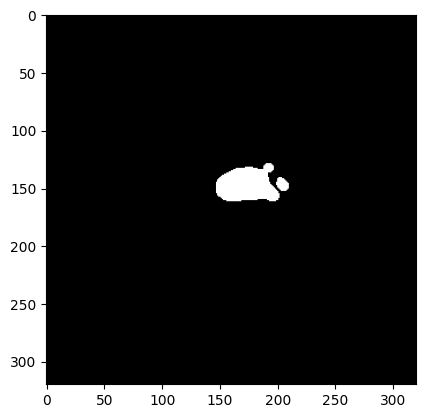

In [88]:
import matplotlib.pyplot as plt
middle_slice = img_data.shape[2]//2
plt.imshow(img_data[:, :, middle_slice], cmap='gray')

# Installing all the dependinces

In [1]:
pwd

'C:\\Users\\prasuna\\OneDrive - Micron Technology, Inc\\Desktop\\BRATS'

In [137]:
import os
os.chdir(r'C:\\Users\\prasuna\\OneDrive - Micron Technology, Inc\\Desktop\\BRATS')

In [138]:
cd nnUNet

C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet


C:\Users\prasuna\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [139]:
pip install -e .

Looking in indexes: https://artifactory.micron.com/artifactory/api/pypi/zextpythonorg-pypi-rel-remote/simple
Obtaining file:///C:/Users/prasuna/OneDrive%20-%20Micron%20Technology%2C%20Inc/Desktop/BRATS/nnUNet
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/18.8 MB ? eta -:--:--
     --------------


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Preprocessing the data

In [118]:
import subprocess

# Define the path to your old dataset and the new dataset name
file_path = r"C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet\nnunetv2\dataset_conversion\convert_raw_dataset_from_old_nnunet_format.py"
old_dataset_path = r"C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\Task02_Heart"
new_dataset_name = "Dataset002_Heart"

# Run the conversion command
subprocess.run([
    file_path,
    old_dataset_path,
    new_dataset_name
], shell=True)


#This will run but this does not work, not able to preprocess the data

CompletedProcess(args=['C:\\Users\\prasuna\\OneDrive - Micron Technology, Inc\\Desktop\\BRATS\\nnUNet\\nnunetv2\\dataset_conversion\\convert_raw_dataset_from_old_nnunet_format.py', 'C:\\Users\\prasuna\\OneDrive - Micron Technology, Inc\\Desktop\\BRATS\\Task02_Heart', 'Dataset002_Heart'], returncode=0)

In [122]:
import sys
sys.path.append(r'C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet')  # Add nnUNet repo to path

In [133]:
# !pip install batchgenerators

In [130]:
from nnunetv2.dataset_conversion.convert_raw_dataset_from_old_nnunet_format import convert

# Define paths
old_dataset_path = r"C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\Task02_Heart"
new_dataset_name = "Dataset002_Heart"

# Run the conversion
convert(old_dataset_path, new_dataset_name)

#Creates problems of path

TypeError: expected str, bytes or os.PathLike object, not NoneType

In [121]:
import os

output_path = r"C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\Dataset002_Heart"
print("Exists:", os.path.exists(output_path))


Exists: False


In [131]:
from nnunetv2.paths import nnUNet_raw

In [1]:
# convert files and dataset into nnunet_v2 format

import os
import json

def rename_files_and_generate_json(dataset_path):
    imagesTr_path = os.path.join(dataset_path, 'imagesTr')
    labelsTr_path = os.path.join(dataset_path, 'labelsTr')
    imagesTs_path = os.path.join(dataset_path, 'imagesTs')

    def rename_files_in_directory(directory):
        if not os.path.exists(directory):
            print(f"Directory not found: {directory}")
            return
        for filename in os.listdir(directory):
            if filename.endswith('.nii.gz') and '_0000' not in filename:
                new_filename = filename.replace('.nii.gz', '_0000.nii.gz')
                os.rename(os.path.join(directory, filename), os.path.join(directory, new_filename))

    rename_files_in_directory(imagesTr_path)
    rename_files_in_directory(imagesTs_path)

    dataset_json = {
        "name": "Heart",
        "description": "Segmentation of the heart in MRI images",
        "tensorImageSize": "4D",
        "modality": {"0": "MRI"},
        "labels": {"0": "background", "1": "heart"},
        "numTraining": 0,
        "numTest": 0,
        "training": [],
        "test": []
    }

    if os.path.exists(imagesTr_path):
        for filename in os.listdir(imagesTr_path):
            if filename.endswith('_0000.nii.gz'):
                label_filename = filename.replace('_0000.nii.gz', '.nii.gz')
                dataset_json["training"].append({
                    "image": f"./imagesTr/{filename}",
                    "label": f"./labelsTr/{label_filename}"
                })
        dataset_json["numTraining"] = len(dataset_json["training"])

    if os.path.exists(imagesTs_path):
        for filename in os.listdir(imagesTs_path):
            if filename.endswith('_0000.nii.gz'):
                dataset_json["test"].append(f"./imagesTs/{filename}")
        dataset_json["numTest"] = len(dataset_json["test"])

    with open(os.path.join(dataset_path, 'dataset.json'), 'w') as f:
        json.dump(dataset_json, f, indent=4)

    print("✅ Files renamed and dataset.json generated successfully.")

rename_files_and_generate_json(r"C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\Task02_Heart")

✅ Files renamed and dataset.json generated successfully.


In [5]:
import os
os.environ["nnUNet_raw"] = r"C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet\nnunetv2\nnUNet_raw"

In [6]:
!nnUNetv2_preprocess -d 2

nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.
nnUNet_results is not defined and nnU-Net cannot be used for training or inference. If this is not intended behavior, please read documentation/setting_up_paths.md for information on how to set this up.
Preprocessing dataset Dataset002_Heart


Traceback (most recent call last):
  File "C:\Users\prasuna\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\prasuna\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\prasuna\AppData\Local\Programs\Python\Python310\Scripts\nnUNetv2_preprocess.exe\__main__.py", line 7, in <module>
  File "C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet\nnunetv2\experiment_planning\plan_and_preprocess_entrypoints.py", line 103, in preprocess_entry
    preprocess(args.d, args.plans_name, configurations=args.c, num_processes=np, verbose=args.verbose)
  File "C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet\nnunetv2\experiment_planning\plan_and_preprocess_api.py", line 150, in preprocess
    preprocess_dataset(d, plans_identifier, configurations, num_processes, verbose)
  File "C:\Users\pr

In [3]:
import os
base_dir = os.path.expanduser(r'C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet')
base_dir

'C:\\Users\\prasuna\\OneDrive - Micron Technology, Inc\\Desktop\\BRATS\\nnUNet'

In [4]:
# make these directories manually

import os

# base_dir = os.path.expanduser('~/nnUNet')
os.makedirs(os.path.join(base_dir, 'nnUNet_raw', 'Task002_Heart'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'nnUNet_preprocessed'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'nnUNet_results'), exist_ok=True)

# Set environment variables
os.environ['nnUNet_raw'] = os.path.join(base_dir, 'nnUNet_raw')
os.environ['nnUNet_preprocessed'] = os.path.join(base_dir, 'nnUNet_preprocessed')
os.environ['nnUNet_results'] = os.path.join(base_dir, 'nnUNet_results')


In [5]:
from nnunetv2.experiment_planning.plan_and_preprocess_api import preprocess_dataset

In [21]:
preprocess_dataset(2)

RuntimeError: Could not find a dataset with the ID 2. Make sure the requested dataset ID exists and that nnU-Net knows where raw and preprocessed data are located (see Documentation - Installation). Here are your currently defined folders:
nnUNet_preprocessed=C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet\nnUNet_preprocessed
nnUNet_results=C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet\nnUNet_results
nnUNet_raw=C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet\nnUNet_raw
If something is not right, adapt your environment variables.

In [19]:
!pip install nnunetv2

Looking in indexes: https://artifactory.micron.com/artifactory/api/pypi/zextpythonorg-pypi-rel-remote/simple
  Using cached https://artifactory.micron.com/artifactory/api/pypi/zextpythonorg-pypi-rel-remote/packages/packages/f2/94/3af39d34be01a24a6e65433d19e107099374224905f1e0cc6bbe1fd22a2f/argparse-1.4.0-py2.py3-none-any.whl (23 kB)



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
!nnUNetv2_plan_and_preprocess -d 2

Fingerprint extraction...


Traceback (most recent call last):
  File "C:\Users\prasuna\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\prasuna\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\prasuna\AppData\Local\Programs\Python\Python310\Scripts\nnUNetv2_plan_and_preprocess.exe\__main__.py", line 7, in <module>
  File "C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet\nnunetv2\experiment_planning\plan_and_preprocess_entrypoints.py", line 180, in plan_and_preprocess_entry
    extract_fingerprints(args.d, args.fpe, args.npfp, args.verify_dataset_integrity, args.clean, args.verbose)
  File "C:\Users\prasuna\OneDrive - Micron Technology, Inc\Desktop\BRATS\nnUNet\nnunetv2\experiment_planning\plan_and_preprocess_api.py", line 47, in extract_fingerprints
    extract_fingerprint_dataset(d, fingerprint_extractor_class, num_

In [44]:
!nnUNetv2_plan_and_preprocess -d 2 --verify_dataset_integrity
#-d 2 is the dataset_id, i.e, the name will be Dataset_002_Heart

Fingerprint extraction...
Dataset002_Heart
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [115. 320. 232.], 3d_lowres: [115, 320, 232]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 40, 'patch_size': (320, 256), 'median_image_size_in_voxels': arra


100%|##########| 20/20 [00:49<00:00,  2.47s/it]

100%|##########| 20/20 [09:13<00:00, 27.67s/it]

100%|##########| 20/20 [04:27<00:00, 13.39s/it]


In [8]:
import os
from nnunetv2.run.run_training import run_training

In [34]:
# Example parameters
dataset_id_for_project = 2  # Replace with your dataset ID
configuration_for_project = '3d_lowres'  # or '3d_fullres', '3d_lowres', etc.
fold_for_project = 0  # or 'all' for all folds
device_for_project = 0  # GPU ID


In [43]:
run_training(
    dataset_name_or_id="Dataset002_Heart",
    configuration="3d_fullres",
    fold=fold_for_project,
    device=torch.device("cpu"), #torch.device("cuda:0")
    disable_checkpointing=False,
    #val=False,  # Set to True if you want validation during training
    #npz=False,  # Set to True if you want to save softmax predictions
    pretrained_weights=None  # Set path if using pretrained weights
)



############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cpu

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2025-06-05 10:31:18.147618: do_dummy_2d_data_aug: False
2025-06-05 10:31:18.151421: Creating new 5-fold cross-validation split...
2025-06-05 10:31:18.157171: Desired fold for training: 0
2025-06-05 10:31:18.158661: This split has 16 training and 4 validation cases.

This is the configuration used b

KeyboardInterrupt: 

In [6]:
os.environ['nnUNet_max_num_epochs'] = '1'
# os.environ['nnUNet_n_proc_DA'] = '0'

In [10]:
import torch

In [11]:
run_training(
    dataset_name_or_id="Dataset002_Heart",
    configuration="3d_fullres",
    fold='all',
    device=torch.device("cpu"), #torch.device("cuda:0")
    disable_checkpointing=False,
    #val=False,  # Set to True if you want validation during training
    #npz=False,  # Set to True if you want to save softmax predictions
    pretrained_weights=None  # Set path if using pretrained weights
)



############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cpu

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2025-06-05 11:10:11.922402: do_dummy_2d_data_aug: False

This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 1, 'patch_size': [48, 96, 96], 'median_image_size_in_voxe

KeyboardInterrupt: 

In [46]:
input_dir = os.path.join(os.environ['nnUNet_raw'], 'Dataset002_Heart', 'imagesTs')
output_dir = './predictions'

!nnUNetv2_predict -d 2 -i {input_dir} -o {output_dir} -c 3d_fullres -f 0



#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################



usage: nnUNetv2_predict [-h] -i I -o O -d D [-p P] [-tr TR] -c C
                        [-f F [F ...]] [-step_size STEP_SIZE] [--disable_tta]
                        [--verbose] [--save_probabilities]
                        [--continue_prediction] [-chk CHK] [-npp NPP]
                        [-nps NPS]
                        [-prev_stage_predictions PREV_STAGE_PREDICTIONS]
                        [-num_parts NUM_PARTS] [-part_id PART_ID]
                        [-device DEVICE] [--disable_progress_bar]
nnUNetv2_predict: error: unrecognized arguments: - Micron Technology, Inc\Desktop\BRATS\nnUNet\nnUNet_raw\Dataset002_Heart\imagesTs


In [12]:
from nnunetv2.paths import nnUNet_results, nnUNet_raw
import torch
from batchgenerators.utilities.file_and_folder_operations import join
from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor

In [13]:
# instantiate the nnUNetPredictor
predictor = nnUNetPredictor(
    tile_step_size=0.5,
    use_gaussian=True,
    use_mirroring=True,
    perform_everything_on_device=True,
    device=torch.device('cuda', 0),
    verbose=False,
    verbose_preprocessing=False,
    allow_tqdm=True
)

In [18]:
from batchgenerators.utilities.file_and_folder_operations import load_json, join
model_training_output_dir = join(nnUNet_results, "Dataset002_Heart\nnUNetTrainer__nnUNetPlans__3d_fullres")
load_json(join(model_training_output_dir, 'dataset.json'))

OSError: [Errno 22] Invalid argument: 'C:\\Users\\prasuna\\OneDrive - Micron Technology, Inc\\Desktop\\BRATS\\nnUNet\\nnUNet_results\\Dataset002_Heart\nnUNetTrainer__nnUNetPlans__3d_fullres\\dataset.json'

In [20]:
# initializes the network architecture, loads the checkpoint
predictor.initialize_from_trained_model_folder(
    join(nnUNet_results, "Dataset002_Heart\\nnUNetTrainer__nnUNetPlans__3d_fullres"),
    use_folds=(0,),
    checkpoint_name='checkpoint_final.pth',
)


In [ ]:
# variant 1: give input and output folders
import torch
predictor.device = torch.device('cpu')
predictor.predict_from_files(join(nnUNet_raw, 'Dataset002_Heart/imagesTs'),
                             join(nnUNet_raw, 'Dataset002_Heart/imagesTs_predlowres'),
                             save_probabilities=False,
                             overwrite=False,
                             num_processes_preprocessing=2,
                             num_processes_segmentation_export=2,
                             folder_with_segs_from_prev_stage=None,
                             num_parts=1,
                             part_id=0)


There are 10 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 10 cases that I would like to predict
overwrite was set to False, so I am only working on cases that haven't been predicted yet. That's 10 cases.

Predicting la_001:
perform_everything_on_device: True


100%|██████████████████████████████████████████████████████████████████████████████████| 64/64 [13:44<00:00, 12.88s/it]


sending off prediction to background worker for resampling and export
done with la_001

Predicting la_002:
perform_everything_on_device: True


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [25:13<00:00, 12.61s/it]


sending off prediction to background worker for resampling and export
done with la_002

Predicting la_006:
perform_everything_on_device: True


...

100%|██████████████████████████████████████████████████████████████████████████████████| 96/96 [22:36<00:00, 14.13s/it]


sending off prediction to background worker for resampling and export
done with la_013

Predicting la_015:
perform_everything_on_device: True


100%|██████████████████████████████████████████████████████████████████████████████████| 96/96 [23:16<00:00, 14.55s/it]


sending off prediction to background worker for resampling and export
done with la_015

Predicting la_025:
perform_everything_on_device: True


 82%|█████████████████████████████████████████████████████████████▎             | 98/120 [17:47:01<2:21:40, 386.37s/it]

In [27]:
dataset_id = 2
startswith = "Dataset%03.0d" % dataset_id
startswith

'Dataset002'

In [38]:
# nnUNet_raw is not None and isdir(nnUNet_raw):
candidates_raw = subdirs(nnUNet_raw, prefix=startswith, join=False)
candidates_raw

['Dataset002_Heart']

In [33]:
from nnunetv2.paths import nnUNet_preprocessed, nnUNet_raw, nnUNet_results
from typing import Union

from nnunetv2.paths import nnUNet_preprocessed, nnUNet_raw, nnUNet_results
from batchgenerators.utilities.file_and_folder_operations import *
import numpy as np

In [34]:
if nnUNet_raw is not None and isdir(nnUNet_raw):
    print("yes")

yes
